# Notebook 3: Competitive Intelligence Analysis

**Analysis pipeline organized in three parts:**

**1. Conventional Analysis**
- Score trends (daily average ratings)
- Review volume (daily comment counts)
- High‑like and low‑score keyword extraction

**2. Quantified Analysis**
- PXI subscale comparison (radar chart)
- Blind‑spot detection (low similarity to PXI)
- Custom dimension definition (from blind‑spot keywords)
- Custom dimension score computation
- Radar chart: custom dimensions by score group
- Custom dimension score table (high vs low score groups)

**3. Exploratory Analysis**
- User flow analysis (RoK → CoC migration)
- Rise of Kingdoms 4‑year trend analysis (weekly, with linear fit)
- Clash of Clans 4‑month trend analysis (daily, with linear fit)

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import ttest_ind
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
os.makedirs("results/figures", exist_ok=True)

# Load cleaned data
coc = pd.read_csv("dataset/coc_clean.csv")
rok = pd.read_csv("dataset/rok_clean.csv")
print(f"CoC: {len(coc)} reviews, RoK: {len(rok)} reviews")

# Load embeddings
with open('processed/coc_embeddings_full.pkl', 'rb') as f:
    coc_emb = pd.DataFrame(pickle.load(f))
with open('processed/rok_embeddings_full.pkl', 'rb') as f:
    rok_emb = pd.DataFrame(pickle.load(f))
print("Embeddings loaded.")

# Load PXI embeddings
with open('processed/pxi_embeddings.pkl', 'rb') as f:
    pxi_df = pd.DataFrame(pickle.load(f))
pxi_embs = np.array(pxi_df['embedding'].tolist())
print("PXI embeddings loaded.")

CoC: 29701 reviews, RoK: 28337 reviews
Embeddings loaded.
PXI embeddings loaded.


In [2]:
from utils import cosine_similarity, aggregate_scores

In [3]:
coc['date'] = pd.to_datetime(coc['date'], errors='coerce')
rok['date'] = pd.to_datetime(rok['date'], errors='coerce')
coc = coc.dropna(subset=['date'])
rok = rok.dropna(subset=['date'])

four_months_ago = datetime.now() - timedelta(days=120)
coc_recent = coc[coc['date'] >= four_months_ago]
rok_recent = rok[rok['date'] >= four_months_ago]

coc_daily = coc_recent.groupby('date')['score'].mean().reset_index()
rok_daily = rok_recent.groupby('date')['score'].mean().reset_index()
coc_vol = coc_recent.groupby('date').size().reset_index(name='count')
rok_vol = rok_recent.groupby('date').size().reset_index(name='count')

# 1. Traditional Analysis
## 1.1 score trendency

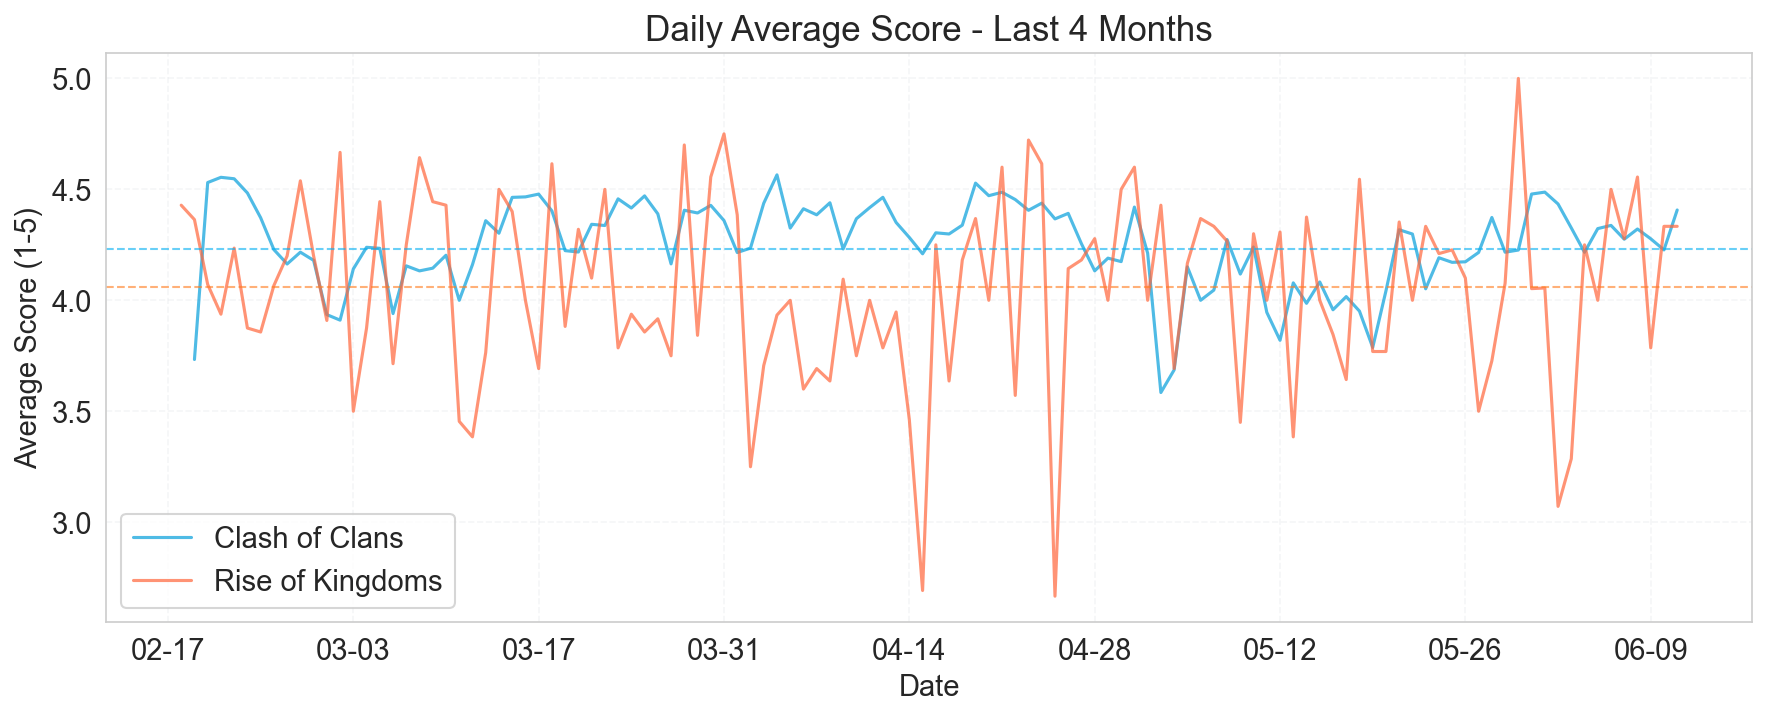

In [4]:
# Set global font size for all text elements
plt.rcParams.update({'font.size': 14})   # Increase font size for axes labels, ticks, legend, title

# coc_daily, rok_daily, coc_avg, rok_avg already defined
coc_avg = coc_recent['score'].mean()
rok_avg = rok_recent['score'].mean()

plt.figure(figsize=(12,5))
plt.plot(coc_daily['date'], coc_daily['score'], color="#059edb", label='Clash of Clans', alpha=0.7)
plt.plot(rok_daily['date'], rok_daily['score'], color="#FF663B", label='Rise of Kingdoms', alpha=0.7)

# Average horizontal lines
plt.axhline(y=coc_avg, color="#03aff2", linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(y=rok_avg, color="#FF7C1E", linestyle='--', linewidth=1, alpha=0.6)

# Grid
plt.grid(True, linestyle='--', alpha=0.4, color='#E5E7EB')

# Date formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xlabel('Date')
plt.ylabel('Average Score (1-5)')
plt.title('Daily Average Score - Last 4 Months')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('results/figures/score_trend_recent.png', dpi=150)
plt.show()

## 1.2 daily reviews count

In [5]:
coc_vol['date'] = pd.to_datetime(coc_vol['date'])
coc_emb['at'] = pd.to_datetime(coc_emb['at'])

peak_dates = coc_vol[coc_vol['count'] > 500]['date'].tolist()

def extract_keywords_by_date(peak_date, df, top_n=5):
    start = pd.Timestamp(peak_date)
    end = start + pd.Timedelta(days=1)
    daily = df[(df['at'] >= start) & (df['at'] < end)]
    if len(daily) < 3:
        return []
    texts = daily['content'].dropna().tolist()
    if not texts:
        return []
    vec = TfidfVectorizer(max_features=top_n, stop_words=None, ngram_range=(1,2), min_df=1)
    tfidf = vec.fit_transform(texts)
    terms = vec.get_feature_names_out()
    scores = tfidf.mean(axis=0).A1
    keywords = pd.Series(scores, index=terms).sort_values(ascending=False)
    return keywords.index.tolist()

peak_keywords = {}
for d in peak_dates:
    kw = extract_keywords_by_date(d, coc_emb, top_n=20)
    peak_keywords[d] = kw
    print(f"{d.date()}: {', '.join(kw)}")

2026-02-23: game, good, it, the, this, and, very, nice, is, best, to, this game, good game, my, of, best game, love, for, but, in
2026-02-24: game, good, this, the, it, is, nice, this game, and, to, best, very, of, my, in, for, time, playing, but, you
2026-04-27: game, the, good, this, is, it, and, best, this game, of, to, very, good game, my, update, for, so, but, in, you
2026-04-28: game, it, good, the, this, is, this game, and, update, to, best, very, of, my, but, so, time, in, for, play
2026-05-04: game, the, good, it, and, this, nice, to, is, of, very, update, for, this game, but, my, in, time, the game, new
2026-05-26: game, the, it, good, this, and, is, nice, best, to, of, update, this game, very, for, but, my, in, you, have


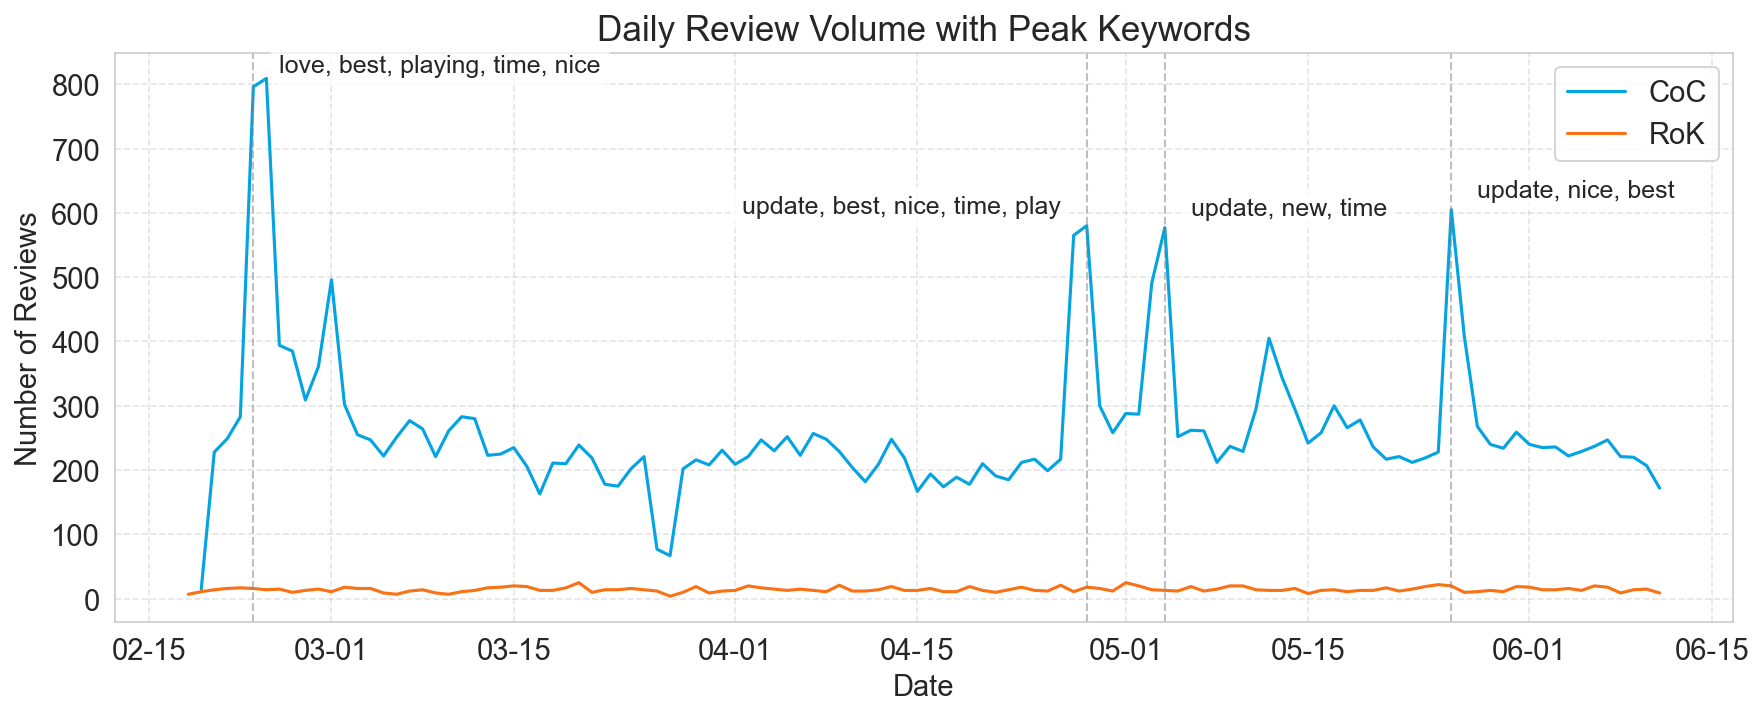

In [6]:
# Set global font size for better readability in PDF
plt.rcParams.update({'font.size': 14})

plt.figure(figsize=(12,5))
plt.plot(coc_vol['date'], coc_vol['count'], color="#04a3e2", label='CoC')
plt.plot(rok_vol['date'], rok_vol['count'], color='#F97316', label='RoK')

annotations = {
    '2026-02-23': ('love, best, playing, time, nice', 'right'),
    '2026-04-28': ('update, best, nice, time, play', 'left'),
    '2026-05-04': ('update, new, time', 'right'),
    '2026-05-26': ('update, nice, best', 'right')
}

coc_vol['date'] = pd.to_datetime(coc_vol['date'])
coc_counts = dict(zip(coc_vol['date'], coc_vol['count']))

for date_str, (kw_text, side) in annotations.items():
    date_obj = pd.to_datetime(date_str)
    if date_obj not in coc_counts:
        continue
    y_peak = coc_counts[date_obj]
    plt.axvline(x=date_obj, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    offset = 2 if side == 'right' else -2
    ha = 'left' if side == 'right' else 'right'
    x_text = date_obj + pd.Timedelta(days=offset)
    y_text = y_peak * 1.02
    plt.text(x_text, y_text, kw_text, ha=ha, va='bottom', fontsize=12,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.2, color='gray')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.title('Daily Review Volume with Peak Keywords')
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/review_volume_keywords.png', dpi=150)
plt.show()

## 1.3 score distribution histogram

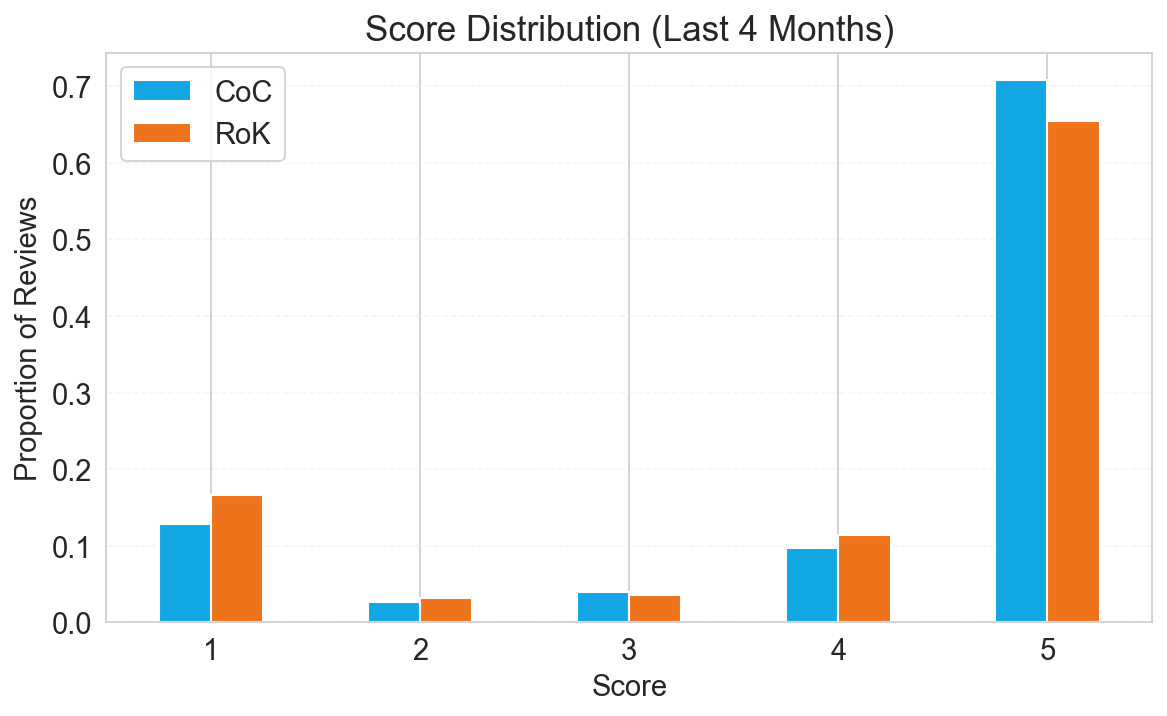

In [7]:
coc_score_counts = coc_recent['score'].value_counts(normalize=True).sort_index()
rok_score_counts = rok_recent['score'].value_counts(normalize=True).sort_index()

score_df = pd.DataFrame({
    'CoC': coc_score_counts,
    'RoK': rok_score_counts
}).fillna(0)

score_df.plot(kind='bar', figsize=(8,5), color=["#12a7e2", "#EE731B"])
plt.xlabel('Score')
plt.ylabel('Proportion of Reviews')
plt.title('Score Distribution (Last 4 Months)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#E5E7EB')
plt.tight_layout()
plt.savefig('results/figures/score_distribution_combined.png', dpi=150)
plt.show()

## 1.4 top comments word clould

In [8]:
def high_likes_keywords(df, col='content', likes_col='likes', top_n=20):
    high = df[df[likes_col] > df[likes_col].quantile(0.9)]
    if len(high) < 10:
        return pd.Series()
    vec = TfidfVectorizer(max_features=top_n, stop_words='english', ngram_range=(1,2))
    tfidf = vec.fit_transform(high[col])
    terms = vec.get_feature_names_out()
    scores = tfidf.mean(axis=0).A1
    return pd.Series(scores, index=terms).sort_values(ascending=False)

coc_high = high_likes_keywords(coc)
rok_high = high_likes_keywords(rok)

print("CoC high-likes keywords:\n", coc_high.head(10))
print("\nRoK high-likes keywords:\n", rok_high.head(10))

CoC high-likes keywords:
 game       0.307231
time       0.088523
good       0.087688
update     0.073868
like       0.070520
play       0.069301
just       0.066217
new        0.065741
playing    0.062690
fun        0.059379
dtype: float64

RoK high-likes keywords:
 game       0.313989
play       0.121289
fun        0.097861
time       0.096540
like       0.096210
good       0.091134
just       0.089270
money      0.086549
players    0.079160
great      0.072218
dtype: float64


## 1.5 low-rating review keywords

In [9]:
def low_score_keywords(df, col='content', top_n=20):
    low = df[df['score'] <= 2]
    if len(low) < 10:
        return pd.Series()
    vec = TfidfVectorizer(max_features=top_n, stop_words='english', ngram_range=(1,2))
    tfidf = vec.fit_transform(low[col])
    terms = vec.get_feature_names_out()
    scores = tfidf.mean(axis=0).A1
    return pd.Series(scores, index=terms).sort_values(ascending=False)

coc_low_kw = low_score_keywords(coc)
rok_low_kw = low_score_keywords(rok)

print("CoC low-score complaints:\n", coc_low_kw.head(10))
print("\nRoK low-score complaints:\n", rok_low_kw.head(10))

CoC low-score complaints:
 game         0.239290
update       0.112551
time         0.068033
fix          0.058498
account      0.054686
play         0.054588
new          0.049751
just         0.046232
supercell    0.042831
good         0.042642
dtype: float64

RoK low-score complaints:
 game       0.279027
play       0.082432
money      0.071274
time       0.064895
just       0.063492
pay        0.060727
account    0.058552
don        0.055279
like       0.051712
players    0.050534
dtype: float64


# 2. PXI Similarity and Blind Spot Detection
## definiation and cosin-similarity calculation

In [10]:
pxi_subscales = {
    'Ease_of_Control': [0,1,2],
    'Goals_and_Rules': [3,4,5],
    'Challenge': [6,7,8],
    'Progress_Feedback': [9,10,11],
    'Audiovisual_Appeal': [12,13,14],
    'Meaning': [15,16,17],
    'Curiosity': [18,19,20],
    'Mastery': [21,22,23],
    'Immersion': [24,25,26],
    'Autonomy': [27,28,29]
}

def compute_pxi_scores(emb_df, pxi_embs, subscales):
    review_embs = np.array(emb_df['embedding'].tolist())
    sim = cosine_similarity(review_embs, pxi_embs)  # (n,30)
    for i in range(sim.shape[1]):
        emb_df[f'cos_sim{i}'] = sim[:, i]
    scores = aggregate_scores(emb_df, subscales)
    return scores

coc_pxi = compute_pxi_scores(coc_emb, pxi_embs, pxi_subscales)
rok_pxi = compute_pxi_scores(rok_emb, pxi_embs, pxi_subscales)
print("PXI scores computed.")

PXI scores computed.


## 2.1 Blind spot detection

In [12]:
# low-similarity comment 
coc_max = coc_pxi.max(axis=1)
rok_max = rok_pxi.max(axis=1)
coc_thresh = np.percentile(coc_max, 5)
rok_thresh = np.percentile(rok_max, 5)

print(f"CoC low similarity threshold (5th percentile): {coc_thresh:.4f}")
print(f"RoK low similarity threshold (5th percentile): {rok_thresh:.4f}")

coc_low_text = coc_emb.loc[coc_max <= coc_thresh, 'content']
rok_low_text = rok_emb.loc[rok_max <= rok_thresh, 'content']

print(f"CoC blind spot reviews: {len(coc_low_text)}")
print(f"RoK blind spot reviews: {len(rok_low_text)}")

CoC low similarity threshold (5th percentile): 0.1320
RoK low similarity threshold (5th percentile): 0.1445
CoC blind spot reviews: 1485
RoK blind spot reviews: 1417


In [13]:
# keyword extraction
def blind_keywords(texts, n=15):
    if len(texts) < 10:
        return pd.Series()
    vec = TfidfVectorizer(max_features=n, stop_words='english', ngram_range=(1,2), min_df=2)
    tfidf = vec.fit_transform(texts)
    terms = vec.get_feature_names_out()
    scores = tfidf.mean(axis=0).A1
    return pd.Series(scores, index=terms).sort_values(ascending=False)

coc_blind = blind_keywords(coc_low_text)
rok_blind = blind_keywords(rok_low_text)

print("CoC blind spot keywords:\n", coc_blind)
print("\nRoK blind spot keywords:\n", rok_blind)

CoC blind spot keywords:
 update       0.062990
time         0.036511
fix          0.035620
account      0.034329
old          0.027287
problem      0.023383
server       0.022138
support      0.021579
app          0.020505
upgrade      0.019390
network      0.019341
supercell    0.018037
open         0.018008
bug          0.017893
help         0.017675
dtype: float64

RoK blind spot keywords:
 add             0.040662
account         0.036811
power           0.029158
money           0.025529
ads             0.024470
just            0.021102
customer        0.020583
app             0.020317
civilization    0.020284
like            0.019777
empire          0.018670
don             0.017820
support         0.017442
persian         0.016966
service         0.014581
dtype: float64


In [14]:
# typical reviews
def show_example_reviews(texts, keywords, n=3):
    # texts: Series of review texts (低相似度评论)
    # keywords: list of words we are interested in
    for kw in keywords:
        print(f"\n--- Keyword: {kw} ---")
        matched = texts[texts.str.contains(kw, case=False, na=False)]
        for idx, rev in matched.head(n).items():
            print(f"Review: {rev[:200]}")
            print("-" * 40)

# 示例：针对 RoK 的 'money', 'ads', 'customer'
show_example_reviews(rok_low_text, ['money', 'ads', 'customer','fix','help','time'], n=2)


--- Keyword: money ---
Review: They stole my money and locked me out of my account I had spent over 3k on. Criminals! Stay Away!
----------------------------------------
Review: very bad money sink for losers
----------------------------------------

--- Keyword: ads ---
Review: i hate your ads. cringe bet bangsa*
----------------------------------------
Review: Please stop spamming me with your trash ads
----------------------------------------

--- Keyword: customer ---
Review: Totally defunct customer service when things go wrong, so frustrating 😤
----------------------------------------
Review: Bad customer service, u reported a bug in a n event and they are replying with automated reply with common issues.
----------------------------------------

--- Keyword: fix ---
Review: Now the app on My HP Chromebook keeps crashing. It has not loaded since the March 1st update. Please fix!
----------------------------------------
Review: Kenapa saya tidak bisa mengirim pesan aliansi ? Tuli

## 2.2. Define Custom Dimensions from Blind Spots

In [15]:
from utils import get_embeddings

custom_queries = pd.DataFrame({
    'query': [
        'Pay to progress',          # Pay_Progress
        'Too many ads',             # Ad_Overload
        'Poor customer support',    # Support_Tech
        'Trust the company'         # Company_Trust  (new)
    ]
})
custom_queries.to_csv('dataset/custom_queries.csv', index=False)

# Generate embeddings (skip if already done)
if not os.path.exists('processed/custom_embeddings.pkl'):
    get_embeddings('dataset/custom_queries.csv', 'processed/custom_embeddings', 'query')
else:
    print("Custom embeddings already exist.")

Custom embeddings already exist.


In [16]:
# Load custom embeddings (now 4 entries)
with open('processed/custom_embeddings.pkl', 'rb') as f:
    custom_df = pd.DataFrame(pickle.load(f))
custom_embs = np.array(custom_df['embedding'].tolist())  # shape (4, 3072)

# Compute scores for CoC and RoK
def compute_custom_scores(emb_df, custom_embs):
    review_embs = np.array(emb_df['embedding'].tolist())
    sim = cosine_similarity(review_embs, custom_embs)  # (n, m)
    # Create column names automatically
    col_names = [f'Custom_{i}' for i in range(sim.shape[1])]
    scores = pd.DataFrame(sim, columns=col_names)
    return scores

coc_custom = compute_custom_scores(coc_emb, custom_embs)
rok_custom = compute_custom_scores(rok_emb, custom_embs)

# Rename columns to meaningful names (order must match your custom_queries)
rename_dict = {
    'Custom_0': 'Pay_Progress',
    'Custom_1': 'Ad_Overload',
    'Custom_2': 'Support_Tech',
    'Custom_3': 'Company_Trust'
}
coc_custom = coc_custom.rename(columns=rename_dict)
rok_custom = rok_custom.rename(columns=rename_dict)

# Add to the original embedding dataframes
coc_emb = pd.concat([coc_emb, coc_custom], axis=1)
rok_emb = pd.concat([rok_emb, rok_custom], axis=1)

print("Custom dimension scores added.")

Custom dimension scores added.


## 2.3 rating-based player segmentation

In [17]:
coc_with_custom = coc_emb.copy()
rok_with_custom = rok_emb.copy()

coc_high = coc_with_custom[coc_with_custom['score'] >= 4]
coc_low = coc_with_custom[coc_with_custom['score'] <= 2]
rok_high = rok_with_custom[rok_with_custom['score'] >= 4]
rok_low = rok_with_custom[rok_with_custom['score'] <= 2]

custom_cols = ['Pay_Progress', 'Ad_Overload', 'Support_Tech','Company_Trust']
mean_custom = pd.DataFrame({
    'CoC_High': coc_high[custom_cols].mean(),
    'CoC_Low': coc_low[custom_cols].mean(),
    'RoK_High': rok_high[custom_cols].mean(),
    'RoK_Low': rok_low[custom_cols].mean()
})
print(mean_custom)

               CoC_High   CoC_Low  RoK_High   RoK_Low
Pay_Progress   0.198308  0.210922  0.217252  0.265608
Ad_Overload    0.190215  0.226136  0.201956  0.241898
Support_Tech   0.124698  0.231751  0.130315  0.242451
Company_Trust  0.150319  0.123156  0.155665  0.136624


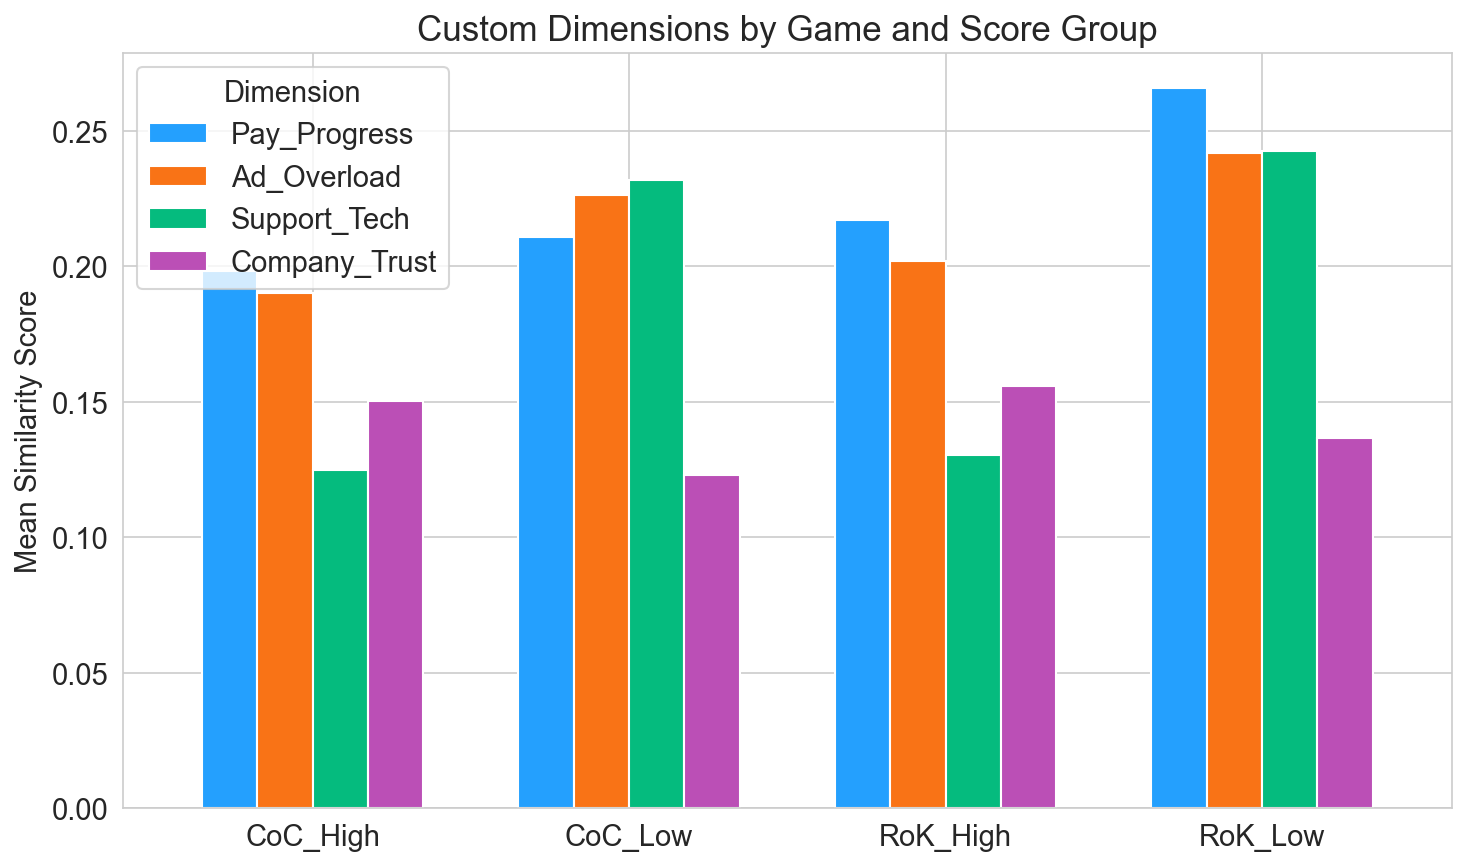

In [18]:
# grouped chart using pandas plot
plot_df = mean_custom.T[['Pay_Progress', 'Ad_Overload', 'Support_Tech','Company_Trust']]
ax = plot_df.plot(kind='bar', figsize=(10,6), color=["#24A0FE", '#F97316', "#05BB7E","#BB4FB6"], width=0.7)
ax.set_ylabel('Mean Similarity Score')
ax.set_title('Custom Dimensions by Game and Score Group')
ax.legend(title='Dimension')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('results/figures/score_group_custom_bars.png')
plt.show()

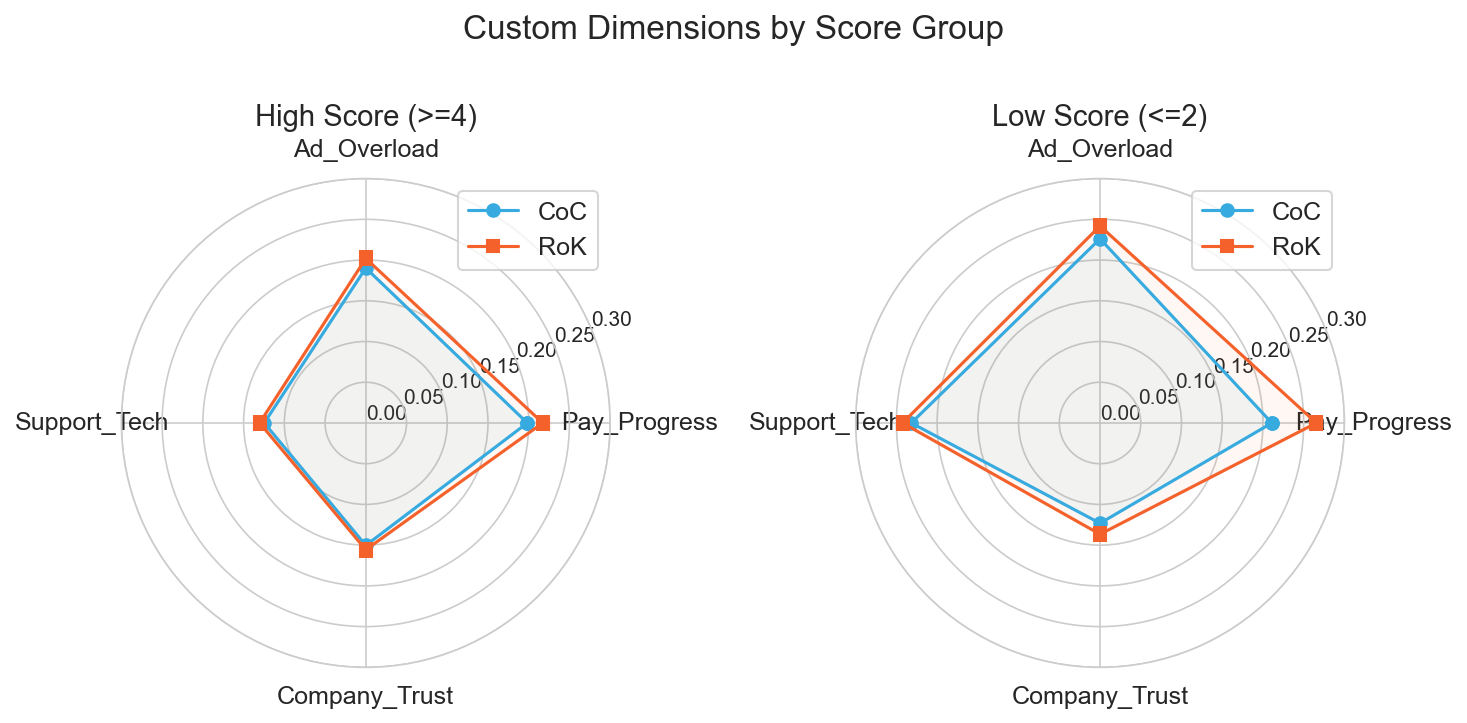

In [19]:
from math import pi

plt.rcParams.update({'font.size': 14})

def plot_radar_group(data_high, data_low, title):
    labels = ['Pay_Progress', 'Ad_Overload', 'Support_Tech', 'Company_Trust']
    N = len(labels)
    angles = np.linspace(0, 2*pi, N, endpoint=False).tolist()
    angles += angles[:1]

    y_min = 0
    y_max = 0.30   
    y_ticks = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

    fig, axes = plt.subplots(1, 2, figsize=(10,5), subplot_kw=dict(polar=True))

    for ax, (group_name, group_data) in zip(axes, [('High Score (>=4)', data_high), ('Low Score (<=2)', data_low)]):
        coc_vals = [group_data['CoC_High'][l] if group_name.startswith('High') else group_data['CoC_Low'][l] for l in labels]
        rok_vals = [group_data['RoK_High'][l] if group_name.startswith('High') else group_data['RoK_Low'][l] for l in labels]
        coc_vals += coc_vals[:1]
        rok_vals += rok_vals[:1]

        ax.plot(angles, coc_vals, marker='o', label='CoC', color="#37AADF")
        ax.plot(angles, rok_vals, marker='s', label='RoK', color="#F5612B")
        ax.fill(angles, coc_vals, alpha=0.05, color='#04a3e2')
        ax.fill(angles, rok_vals, alpha=0.05, color='#F97316')

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=12)
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_ticks)
        ax.tick_params(axis='y', labelsize=10)

        ax.set_title(group_name, fontsize=14)
        ax.legend(fontsize=12)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig('results/figures/radar_score_groups.png', dpi=150)
    plt.show()

plot_radar_group(mean_custom, mean_custom, 'Custom Dimensions by Score Group')

## 2.4 Radar Chart: Overall Comparison

In [20]:
# Calculate means
coc_pxi_mean = coc_pxi.mean()
rok_pxi_mean = rok_pxi.mean()

# Difference (CoC - RoK)
diff = coc_pxi_mean - rok_pxi_mean
diff_sorted = diff.abs().sort_values(ascending=False)

# Print sorted table
pxi_comparison = pd.DataFrame({
    'CoC': coc_pxi_mean,
    'RoK': rok_pxi_mean,
    'Diff (CoC - RoK)': diff
}).loc[diff_sorted.index]
print(pxi_comparison.round(4))

                       CoC     RoK  Diff (CoC - RoK)
Autonomy            0.2211  0.2408           -0.0197
Challenge           0.2547  0.2739           -0.0191
Audiovisual_Appeal  0.2731  0.2890           -0.0159
Ease_of_Control     0.2203  0.2352           -0.0149
Goals_and_Rules     0.2219  0.2365           -0.0146
Mastery             0.2675  0.2782           -0.0107
Meaning             0.2737  0.2834           -0.0098
Curiosity           0.2230  0.2325           -0.0095
Progress_Feedback   0.2269  0.2347           -0.0078
Immersion           0.2094  0.2150           -0.0056


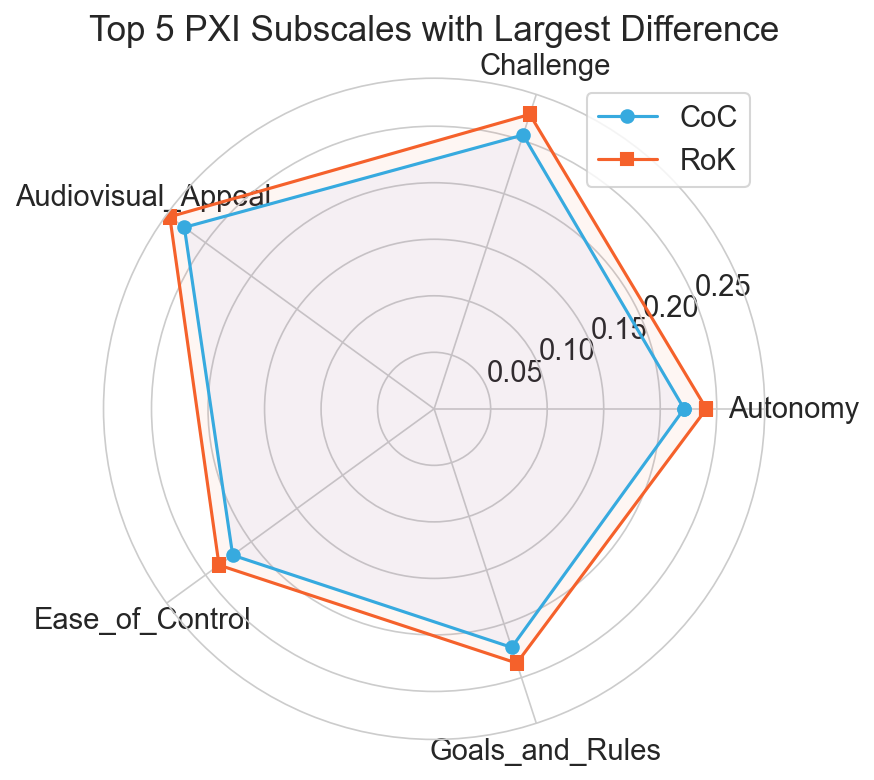

In [21]:
# Select top 5 dimensions with largest difference (adjustable)
top5_dims = diff_sorted.head(5).index.tolist()
coc_vals = coc_pxi_mean[top5_dims].values
rok_vals = rok_pxi_mean[top5_dims].values

# Prepare radar chart
N = len(top5_dims)
angles = np.linspace(0, 2*pi, N, endpoint=False).tolist()
angles += angles[:1]
coc_vals_closed = coc_vals.tolist() + [coc_vals[0]]
rok_vals_closed = rok_vals.tolist() + [rok_vals[0]]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, coc_vals_closed, marker='o', label='CoC', color="#37AADF")
ax.plot(angles, rok_vals_closed, marker='s', label='RoK', color="#F5612B")
ax.fill(angles, coc_vals_closed, alpha=0.05, color='#3B82F6')
ax.fill(angles, rok_vals_closed, alpha=0.05, color="#FB5127")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(top5_dims)
ax.legend()
ax.set_title('Top 5 PXI Subscales with Largest Difference')
plt.tight_layout()
plt.savefig('results/figures/pxi_top5_radar.png')
plt.show()

# 3 Exploratory Data Analysis
## 3.1 mutual players

Common users: 301
direction
RoK_to_CoC    280
CoC_to_RoK     20
Name: count, dtype: int64


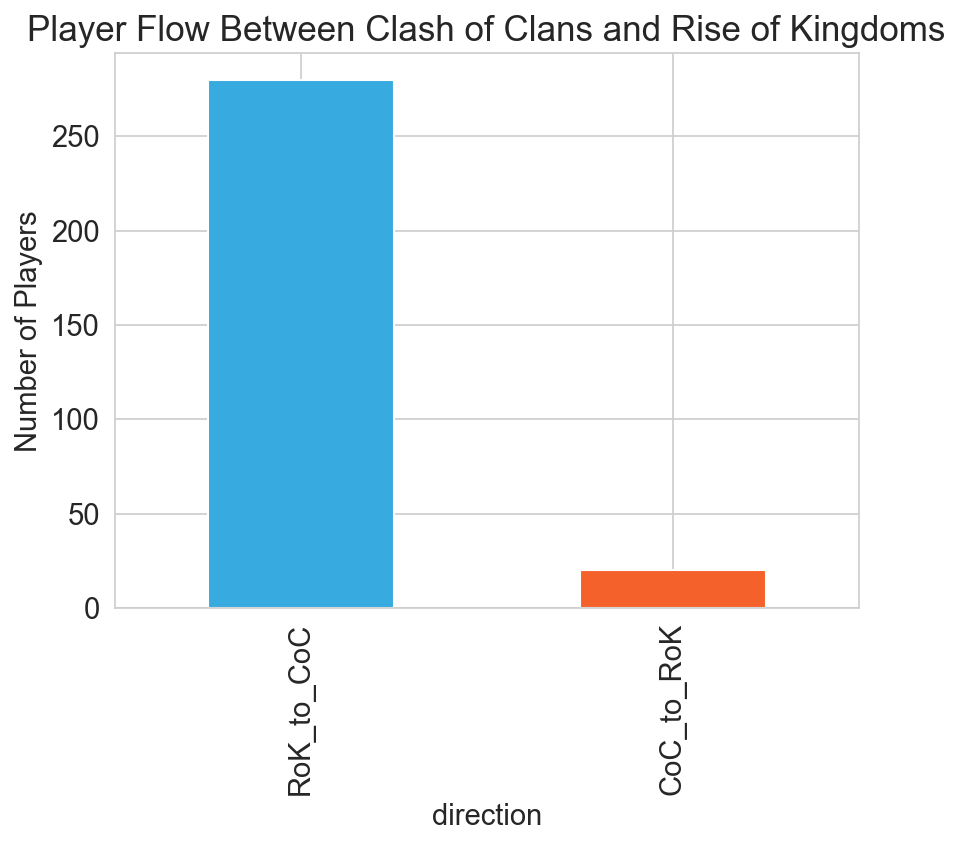

RoK->CoC users: 280
count    280.000000
mean       3.960714
std        1.613749
min        1.000000
25%        3.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: score_rok, dtype: float64
count    280.000000
mean       3.967857
std        1.550478
min        1.000000
25%        3.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: score_coc, dtype: float64
Average rating in RoK: 3.96
Average rating in CoC: 3.97


In [25]:
# Merge username and time info
coc_users = coc[['userName', 'at']].drop_duplicates('userName')
rok_users = rok[['userName', 'at']].drop_duplicates('userName')

# Find common users
common = set(coc_users['userName']).intersection(set(rok_users['userName']))
print(f"Common users: {len(common)}")

# Get earliest review time per user per game
coc_first = coc_users[coc_users['userName'].isin(common)].groupby('userName')['at'].min()
rok_first = rok_users[rok_users['userName'].isin(common)].groupby('userName')['at'].min()

# Merge
flow = pd.DataFrame({'coc_first': coc_first, 'rok_first': rok_first}).dropna()
flow['direction'] = 'unknown'
flow.loc[flow['coc_first'] < flow['rok_first'], 'direction'] = 'CoC_to_RoK'   # 改为下划线
flow.loc[flow['coc_first'] > flow['rok_first'], 'direction'] = 'RoK_to_CoC'   # 改为下划线

# Statistics
direction_counts = flow['direction'].value_counts()
print(direction_counts)

# Visualization
direction_counts.plot(kind='bar', color=['#37AADF', '#F5612B', '#6B7280'])
plt.title('Player Flow Between Clash of Clans and Rise of Kingdoms')
plt.ylabel('Number of Players')
plt.show()

# Extract users who moved from RoK to CoC (now using the same label)
rok_to_coc_users = flow[flow['direction'] == 'RoK_to_CoC'].index.tolist()
print(f"RoK->CoC users: {len(rok_to_coc_users)}")

# Get scores for these users in both games
rok_scores = rok[rok['userName'].isin(rok_to_coc_users)][['userName', 'score']].drop_duplicates('userName')
coc_scores = coc[coc['userName'].isin(rok_to_coc_users)][['userName', 'score']].drop_duplicates('userName')

combined_scores = pd.merge(rok_scores, coc_scores, on='userName', suffixes=('_rok', '_coc'))
print(combined_scores['score_rok'].describe())
print(combined_scores['score_coc'].describe())

# Average scores
print(f"Average rating in RoK: {combined_scores['score_rok'].mean():.2f}")
print(f"Average rating in CoC: {combined_scores['score_coc'].mean():.2f}")

Data time windows:

- Clash of Clans (CoC): Reviews collected from the last 4 months only.

- Rise of Kingdoms (RoK): Reviews collected from the last 4 years (full dataset).

Consequence: A user who posted a review on RoK two years ago and then posted a review on CoC within the last 4 months will be counted as RoK → CoC. A user who first commented on CoC (must be within the last 4 months) and then on RoK (also within the last 4 months) is very rare, because RoK has very few recent comments (sometimes zero).

Thus, the observed asymmetry is an artifact of data collection, not necessarily a real player migration trend. A fair comparison would require restricting both datasets to the same time window, but that would make the RoK sample too small for meaningful analysis.

Conclusion: The flow numbers should be interpreted with caution, and this limitation must be stated in any report.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Collect comments from CoC made by these users
coc_moved = coc[coc['userName'].isin(rok_to_coc_users)]
if len(coc_moved) > 50:
    vectorizer = TfidfVectorizer(max_features=20, stop_words='english', ngram_range=(1,2))
    tfidf = vectorizer.fit_transform(coc_moved['content'])
    terms = vectorizer.get_feature_names_out()
    scores = tfidf.mean(axis=0).A1
    keywords = pd.Series(scores, index=terms).sort_values(ascending=False)
    print("Top keywords in CoC comments from RoK→CoC users:")
    print(keywords.head(10))
else:
    print("Not enough comments to extract keywords.")

Top keywords in CoC comments from RoK→CoC users:
game         0.271308
good         0.106038
fun          0.073849
best         0.065693
play         0.054401
nice         0.053703
love         0.052579
time         0.051979
good game    0.047538
great        0.046744
dtype: float64


## 3.2 RoK yearly analysis

In [29]:
rok_emb['at'] = pd.to_datetime(rok_emb['at'])

# groupby monthly
rok_emb['month'] = rok_emb['at'].dt.to_period('M')
monthly = rok_emb.groupby('month')[['Pay_Progress', 'Ad_Overload', 'Support_Tech','Company_Trust']].mean()
monthly.index = monthly.index.astype(str)  # 转为字符串用于绘图

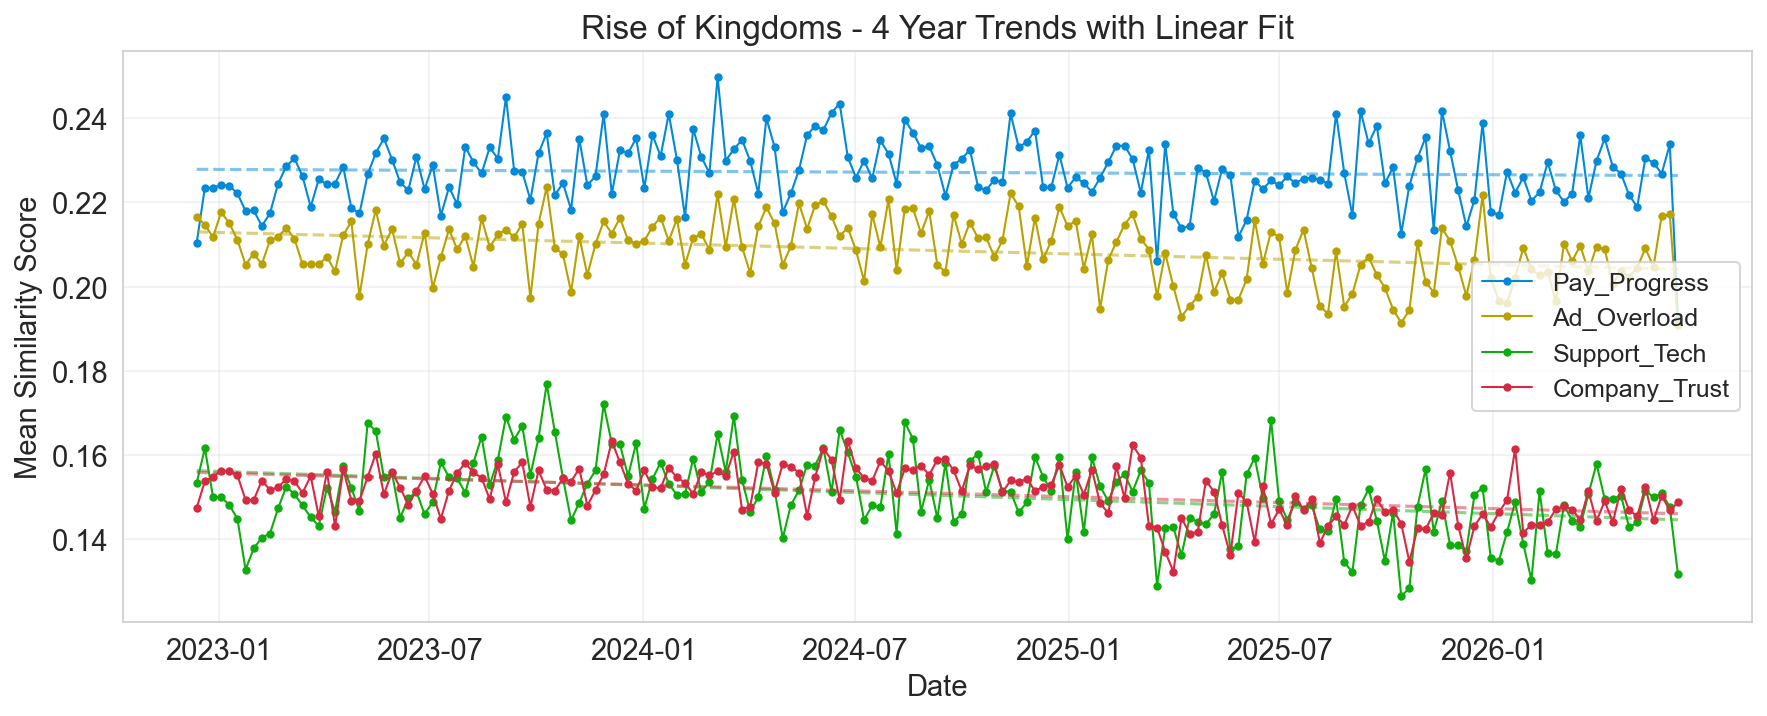

Slope table for Rise of Kingdoms (weekly, 4 years):
Pay_Progress: -0.000008
Ad_Overload: -0.000049
Support_Tech: -0.000064
Company_Trust: -0.000054


In [30]:
# Set global font size for better readability
plt.rcParams.update({'font.size': 14})

# Ensure date column is datetime
rok_emb['at'] = pd.to_datetime(rok_emb['at'])

# Weekly aggregation (Monday as start)
rok_emb['week_start'] = rok_emb['at'].dt.to_period('W-MON').dt.start_time
weekly_rok = rok_emb.groupby('week_start')[['Pay_Progress', 'Ad_Overload', 'Support_Tech','Company_Trust']].mean()
x_numeric = np.arange(len(weekly_rok))

slopes_rok = {}

fig, ax = plt.subplots(figsize=(12,5))
colors_rok = {"Pay_Progress":"#0289d8", "Ad_Overload":"#b9a102", "Support_Tech":"#0ead0e", "Company_Trust":"#d62a43"}

for col, color in colors_rok.items():
    y = weekly_rok[col].values
    ax.plot(weekly_rok.index, y, marker='.', label=col, color=color, linewidth=1)
    coeffs = np.polyfit(x_numeric, y, 1)
    slope, intercept = coeffs
    slopes_rok[col] = slope
    fit_line = np.polyval(coeffs, x_numeric)
    ax.plot(weekly_rok.index, fit_line, linestyle='--', color=color, alpha=0.5)

# Set x-axis ticks to 1st of Jan and Jul only
years = range(weekly_rok.index.min().year, weekly_rok.index.max().year + 1)
tick_positions = []
for y in years:
    for m in [1, 7]:
        tick_positions.append(pd.Timestamp(y, m, 1))
tick_positions = [t for t in tick_positions if weekly_rok.index.min() <= t <= weekly_rok.index.max()]
ax.set_xticks(tick_positions)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Labels and title
plt.xlabel('Date', fontsize=14)
plt.ylabel('Mean Similarity Score', fontsize=14)
plt.title('Rise of Kingdoms - 4 Year Trends with Linear Fit', fontsize=16)

# Place legend inside the plot, center right
plt.legend(loc='center right', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/rok_weekly_trends_fit.png')
plt.show()

# Output slope table
print("Slope table for Rise of Kingdoms (weekly, 4 years):")
for dim, s in slopes_rok.items():
    print(f"{dim}: {s:.6f}")

## 3.3 CoC daily

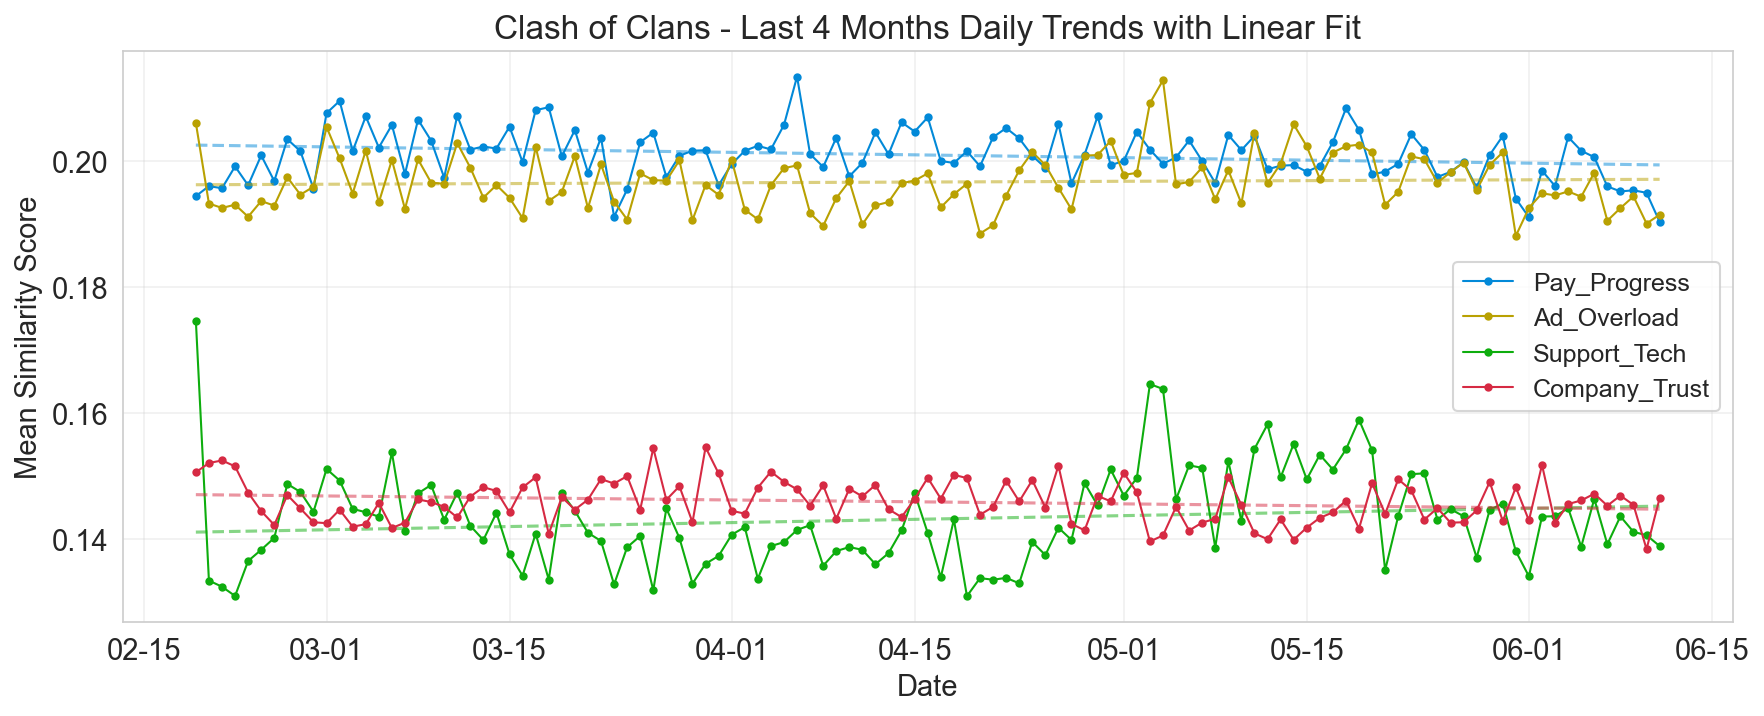

Slope table for Clash of Clans (daily, last 4 months):
Pay_Progress: -0.000028
Ad_Overload: 0.000008
Support_Tech: 0.000037
Company_Trust: -0.000021


In [31]:
# Set global font size for better readability
plt.rcParams.update({'font.size': 14})

# CoC: daily aggregation (last 4 months)
coc_emb['at'] = pd.to_datetime(coc_emb['at'])
four_months_ago = pd.Timestamp.now() - pd.Timedelta(days=120)
coc_4m = coc_emb[coc_emb['at'] >= four_months_ago].copy()
coc_daily = coc_4m.groupby(coc_4m['at'].dt.date)[['Pay_Progress', 'Ad_Overload', 'Support_Tech','Company_Trust']].mean()
coc_daily.index = pd.to_datetime(coc_daily.index)
x_numeric_coc = np.arange(len(coc_daily))

slopes_coc = {}

plt.figure(figsize=(12,5))
# Use the same color scheme as in RoK plot
colors_coc = {"Pay_Progress":"#0289d8", "Ad_Overload":"#b9a102", "Support_Tech":"#0ead0e", "Company_Trust":"#d62a43"}

for col, color in colors_coc.items():
    y = coc_daily[col].values
    plt.plot(coc_daily.index, y, marker='.', label=col, color=color, linewidth=1)
    coeffs = np.polyfit(x_numeric_coc, y, 1)
    slope, intercept = coeffs
    slopes_coc[col] = slope
    fit_line = np.polyval(coeffs, x_numeric_coc)
    plt.plot(coc_daily.index, fit_line, linestyle='--', color=color, alpha=0.5)

plt.xlabel('Date', fontsize=14)
plt.ylabel('Mean Similarity Score', fontsize=14)
plt.title('Clash of Clans - Last 4 Months Daily Trends with Linear Fit', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('results/figures/coc_daily_trends_fit.png')
plt.show()

# Output slope table
print("Slope table for Clash of Clans (daily, last 4 months):")
for dim, s in slopes_coc.items():
    print(f"{dim}: {s:.6f}")
